# Classificação de Câncer de Pulmão com CNNs

Este notebook usa o dataset [IQ-OTH/NCCD](https://data.mendeley.com/datasets/bhmdr45bh2/4) em JPG para treinar um classificador de imagens com `TensorFlow/Keras`.

## Objetivo

- entrada: uma imagem de slice de CT em formato JPG
- classes de origem: `Normal cases`, `Bengin cases` (nomeado dessa forma pelo dataset) e `Malignant cases`
- alvo de treino: `0 = nao_maligno`, `1 = maligno`
- saída final: probabilidade de malignidade da imagem

O fluxo do notebook cobre preparação dos dados, definição do modelo, treino, avaliação e inferência com exemplos reais.

## Bibliotecas Utilizadas

Esta etapa carrega as bibliotecas usadas ao longo do notebook:
- `pathlib` e `json`: leitura de arquivos, caminhos e metadados do modelo salvo
- `pandas` e `numpy`: organização dos registros e manipulação de arrays
- `matplotlib`: visualização de exemplos, curvas e matriz de confusão
- `tensorflow/keras`: construção, treino e inferência do modelo de imagem
- `sklearn`: split estratificado e metricas de avaliação


In [1]:

from pathlib import Path
import json
import random
from zipfile import ZipFile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)


## Funções Auxiliares

Esta seção concentra a base do pipeline de dados do notebook. As funções aqui:
- leem a estrutura de pastas do dataset e transformam os arquivos em um DataFrame
- criam os conjuntos de treino, validação e teste com estratificação
- carregam e redimensionam as imagens para o formato esperado pela rede
- calculam `class_weight` e exibem amostras para inspeção visual


In [2]:

CLASS_INFO = {
    "Normal cases": {"label": 0, "display": "Normal"},
    "Bengin cases": {"label": 0, "display": "Benigno"},
    "Malignant cases": {"label": 1, "display": "Maligno"},
}

LABEL_NAMES = {
    0: "nao_maligno",
    1: "maligno",
}

PREDICTION_DISPLAY = {
    "nao_maligno": "Nao maligno",
    "maligno": "Maligno",
}


def nome_exibicao_classe(nome_pasta):
    return CLASS_INFO[nome_pasta]["display"]


def definir_semente(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


def coletar_registros_imagens(dataset_dir):
    dataset_dir = Path(dataset_dir)
    linhas = []
    for nome_pasta, info in CLASS_INFO.items():
        pasta = dataset_dir / nome_pasta
        if not pasta.exists():
            print(f"Aviso: pasta nao encontrada: {pasta}")
            continue
        for image_path in sorted(pasta.glob("*.jpg")):
            linhas.append(
                {
                    "image_path": str(image_path),
                    "classe_original": nome_pasta,
                    "label": info["label"],
                }
            )
    if not linhas:
        raise FileNotFoundError(f"Nenhuma imagem JPG foi encontrada em {dataset_dir}")
    frame = pd.DataFrame(linhas)
    return frame.sample(frac=1.0, random_state=42).reset_index(drop=True)


def resumir_dataset(registros):
    print("Contagem por rotulo binario:")
    print(registros["label"].value_counts().sort_index().rename(index=LABEL_NAMES))
    print()
    print("Contagem por classe:")
    print(registros["classe_original"].map(nome_exibicao_classe).value_counts().sort_index())


def split_estratificado(registros, seed=42, val_fraction=0.15, test_fraction=0.15):
    if val_fraction + test_fraction >= 1.0:
        raise ValueError("val_fraction + test_fraction deve ser menor que 1.")

    temp_fraction = val_fraction + test_fraction
    treino_df, temp_df = train_test_split(
        registros,
        test_size=temp_fraction,
        stratify=registros["label"],
        random_state=seed,
    )

    fracao_teste_relativa = test_fraction / temp_fraction
    val_df, teste_df = train_test_split(
        temp_df,
        test_size=fracao_teste_relativa,
        stratify=temp_df["label"],
        random_state=seed,
    )

    treino_df = treino_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    teste_df = teste_df.reset_index(drop=True)
    return treino_df, val_df, teste_df


def carregar_tensor_imagem(image_path, image_size=224):
    image = keras.utils.load_img(
        image_path,
        color_mode="rgb",
        target_size=(image_size, image_size),
    )
    array = keras.utils.img_to_array(image).astype("float32")
    return array


def montar_dataset_numpy(registros, image_size=224):
    imagens = []
    labels = []
    for row in tqdm(registros.itertuples(index=False), total=len(registros), desc="Carregando imagens"):
        imagens.append(carregar_tensor_imagem(row.image_path, image_size=image_size))
        labels.append(float(row.label))
    x = np.asarray(imagens, dtype=np.float32)
    y = np.asarray(labels, dtype=np.float32)
    return x, y


def calcular_class_weights(y_train):
    y_train = np.asarray(y_train).astype(np.int32)
    total = len(y_train)
    negativos = max(int(np.sum(y_train == 0)), 1)
    positivos = max(int(np.sum(y_train == 1)), 1)
    return {
        0: total / (2.0 * negativos),
        1: total / (2.0 * positivos),
    }


def mostrar_exemplos(registros, amostras_por_classe=3, image_size=224):
    fig, axes = plt.subplots(len(CLASS_INFO), amostras_por_classe, figsize=(4 * amostras_por_classe, 9))
    if amostras_por_classe == 1:
        axes = np.expand_dims(axes, axis=1)

    for row_index, nome_pasta in enumerate(CLASS_INFO):
        subconjunto = registros[registros["classe_original"] == nome_pasta].head(amostras_por_classe)
        for col_index in range(amostras_por_classe):
            ax = axes[row_index, col_index]
            ax.axis("off")
            if col_index >= len(subconjunto):
                continue
            image_path = subconjunto.iloc[col_index]["image_path"]
            image = keras.utils.load_img(
                image_path,
                color_mode="rgb",
                target_size=(image_size, image_size),
            )
            ax.imshow(image)
            ax.set_title(nome_exibicao_classe(nome_pasta))

    plt.tight_layout()
    plt.show()


## Modelo

Nesta etapa o notebook define a arquitetura usada no experimento. A estrategia escolhida foi `transfer learning` com `EfficientNetB0`, o que reaproveita pesos treinados no ImageNet e reduz o custo de treinar uma rede do zero.

O pipeline do modelo aplica aumento de dados, preprocessamento específico da EfficientNet, pooling global e uma camada densa binaria para classificar a imagem como `nao_maligno` ou `maligno`.

In [3]:

def criar_metricas_modelo():
    return [
        "accuracy",
        keras.metrics.AUC(name="auc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ]


def construir_modelo(image_size=224, fine_tune=False, learning_rate=1e-4):
    aumento_dados = keras.Sequential(
        [
            keras.layers.RandomFlip("horizontal"),
            keras.layers.RandomRotation(0.03),
            keras.layers.RandomZoom(0.08),
            keras.layers.RandomContrast(0.1),
        ],
        name="aumento_dados",
    )

    base_model = keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(image_size, image_size, 3),
    )
    base_model.trainable = fine_tune

    inputs = keras.Input(shape=(image_size, image_size, 3))
    x = aumento_dados(inputs)
    x = keras.applications.efficientnet.preprocess_input(x)
    x = base_model(x, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.35)(x)
    x = keras.layers.Dense(128, activation="relu")(x)
    x = keras.layers.Dropout(0.2)(x)
    outputs = keras.layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=criar_metricas_modelo(),
    )
    return model, base_model


## Funções de Treino e Avaliação

Esta seção organiza a parte experimental do notebook. Ela é responsável por:
- calcular metricas binárias a partir das probabilidades previstas
- escolher o melhor limiar com prioridade para `recall`, reduzindo o risco de falsos negativos
- configurar callbacks de checkpoint, `early stopping` e redução de taxa de aprendizado
- treinar o modelo em duas fases: frozen head e fine-tuning das ultimas camadas
- salvar artefatos como `best.keras`, metadados e métricas em JSON


In [4]:

def calcular_metricas_binarias(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(np.int32)
    y_prob = np.asarray(y_prob).astype(np.float32)
    y_pred = (y_prob >= threshold).astype(np.int32)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    accuracy = float((tp + tn) / max(len(y_true), 1))
    precision = float(tp / max(tp + fp, 1))
    recall = float(tp / max(tp + fn, 1))
    specificity = float(tn / max(tn + fp, 1))
    f1 = float((2 * precision * recall) / max(precision + recall, 1e-8))

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": f1,
        "tp": int(tp),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
    }


def escolher_melhor_limiar(y_true, y_prob, prioridade="recall"):
    y_true = np.asarray(y_true).astype(np.int32)
    y_prob = np.asarray(y_prob).astype(np.float32)
    candidatos = np.linspace(0.1, 0.9, 81)

    melhor_threshold = 0.5
    melhor_metricas = None
    melhor_score = -1.0

    for threshold in candidatos:
        metricas = calcular_metricas_binarias(y_true, y_prob, threshold=threshold)
        if prioridade == "recall":
            score = metricas["recall"] * 2.0 + metricas["specificity"] + metricas["f1"]
        else:
            score = metricas["accuracy"] + metricas["f1"]
        if score > melhor_score:
            melhor_score = score
            melhor_threshold = float(threshold)
            melhor_metricas = metricas

    return melhor_threshold, melhor_metricas


def avaliar_probabilidades(y_true, y_prob, threshold=0.5):
    metricas = calcular_metricas_binarias(y_true, y_prob, threshold=threshold)
    y_true = np.asarray(y_true).astype(np.int32)
    y_prob = np.asarray(y_prob).astype(np.float32)

    try:
        auc_roc = float(roc_auc_score(y_true, y_prob))
    except ValueError:
        auc_roc = None

    try:
        avg_precision = float(average_precision_score(y_true, y_prob))
    except ValueError:
        avg_precision = None

    metricas["auc_roc"] = auc_roc
    metricas["average_precision"] = avg_precision
    metricas["threshold"] = float(threshold)
    return metricas


def criar_callbacks(checkpoint_path):
    return [
        keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_auc",
            mode="max",
            save_best_only=True,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=4,
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
        ),
    ]


def treinar_modelo(
    dataset_dir,
    output_dir,
    epochs=8,
    batch_size=16,
    lr=1e-4,
    image_size=224,
    val_fraction=0.15,
    test_fraction=0.15,
    seed=42,
    usar_class_weight=True,
    fine_tune_epochs=3,
):
    definir_semente(seed)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    registros = coletar_registros_imagens(dataset_dir)
    resumir_dataset(registros)
    registros.to_csv(output_dir / "all_records.csv", index=False)

    treino_df, val_df, teste_df = split_estratificado(
        registros,
        seed=seed,
        val_fraction=val_fraction,
        test_fraction=test_fraction,
    )
    treino_df.to_csv(output_dir / "train_records.csv", index=False)
    val_df.to_csv(output_dir / "val_records.csv", index=False)
    teste_df.to_csv(output_dir / "test_records.csv", index=False)

    x_train, y_train = montar_dataset_numpy(treino_df, image_size=image_size)
    x_val, y_val = montar_dataset_numpy(val_df, image_size=image_size)
    x_test, y_test = montar_dataset_numpy(teste_df, image_size=image_size)

    class_weight = calcular_class_weights(y_train) if usar_class_weight else None
    print("Class weights:", class_weight)

    model, base_model = construir_modelo(
        image_size=image_size,
        fine_tune=False,
        learning_rate=lr,
    )

    checkpoint_path = output_dir / "best.keras"
    callbacks = criar_callbacks(checkpoint_path)

    history_inicial = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1,
        class_weight=class_weight,
    )

    histories = [history_inicial.history]

    if fine_tune_epochs > 0:
        base_model.trainable = True
        for layer in base_model.layers[:-20]:
            layer.trainable = False

        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=lr / 10.0),
            loss="binary_crossentropy",
            metrics=criar_metricas_modelo(),
        )

        history_finetune = model.fit(
            x_train,
            y_train,
            validation_data=(x_val, y_val),
            epochs=fine_tune_epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=1,
            class_weight=class_weight,
        )
        histories.append(history_finetune.history)

    melhor_modelo = keras.models.load_model(checkpoint_path)

    y_prob_val = melhor_modelo.predict(x_val, verbose=0).ravel()
    melhor_threshold, metricas_val = escolher_melhor_limiar(y_val, y_prob_val, prioridade="recall")

    y_prob_test = melhor_modelo.predict(x_test, verbose=0).ravel()
    metricas_teste = avaliar_probabilidades(y_test, y_prob_test, threshold=melhor_threshold)

    history_total = {}
    for hist in histories:
        for chave, valores in hist.items():
            history_total.setdefault(chave, []).extend(valores)

    metadata = {
        "image_size": image_size,
        "class_names": LABEL_NAMES,
        "positive_class": "maligno",
        "negative_class": "nao_maligno",
        "dataset_dir": str(dataset_dir),
        "best_threshold": float(melhor_threshold),
        "class_weight": class_weight,
        "fine_tune_epochs": int(fine_tune_epochs),
        "backbone": "EfficientNetB0",
    }

    with (output_dir / "best_info.json").open("w", encoding="utf-8") as file:
        json.dump(metadata, file, indent=2)

    with (output_dir / "metrics.json").open("w", encoding="utf-8") as file:
        json.dump(
            {
                "history": history_total,
                "validation_metrics": metricas_val,
                "test_metrics": metricas_teste,
                "train_images": len(treino_df),
                "val_images": len(val_df),
                "test_images": len(teste_df),
                **metadata,
            },
            file,
            indent=2,
        )

    print("Modelo salvo em:", checkpoint_path)
    print("Melhor limiar encontrado na validacao:", round(melhor_threshold, 4))
    print("Metricas de teste:", metricas_teste)

    resultados = {
        "treino_df": treino_df,
        "val_df": val_df,
        "teste_df": teste_df,
        "x_test": x_test,
        "y_test": y_test,
        "y_prob_test": y_prob_test,
        "melhor_threshold": melhor_threshold,
        "metricas_teste": metricas_teste,
    }
    return melhor_modelo, history_total, resultados


def plotar_curvas_treino(history):
    if not history:
        print("Historico vazio.")
        return

    metricas = [
        ("loss", "Loss"),
        ("accuracy", "Accuracy"),
        ("auc", "AUC"),
        ("recall", "Recall"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.ravel()

    for ax, (chave, titulo) in zip(axes, metricas):
        ax.plot(history.get(chave, []), label="treino")
        ax.plot(history.get(f"val_{chave}", []), label="validacao")
        ax.set_title(titulo)
        ax.legend()

    plt.tight_layout()
    plt.show()


def plotar_matriz_confusao(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(np.int32)
    y_pred = (np.asarray(y_prob) >= threshold).astype(np.int32)
    matriz = confusion_matrix(y_true, y_pred, labels=[0, 1])

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(matriz, cmap="Blues")
    ax.set_title("Matriz de Confusao")
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
    ax.set_xticks([0, 1], ["nao_maligno", "maligno"])
    ax.set_yticks([0, 1], ["nao_maligno", "maligno"])

    for i in range(matriz.shape[0]):
        for j in range(matriz.shape[1]):
            ax.text(j, i, str(matriz[i, j]), ha="center", va="center", color="black")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


def plotar_curva_roc(y_true, y_prob):
    y_true = np.asarray(y_true).astype(np.int32)
    y_prob = np.asarray(y_prob).astype(np.float32)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], "--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Curva ROC")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plotar_curva_precision_recall(y_true, y_prob):
    y_true = np.asarray(y_true).astype(np.int32)
    y_prob = np.asarray(y_prob).astype(np.float32)
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)

    plt.figure(figsize=(5, 4))
    plt.plot(recall, precision, label=f"AP = {ap:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Curva Precision-Recall")
    plt.legend()
    plt.tight_layout()
    plt.show()


## Caminhos e Configurações

Ajuste os caminhos e hiperparâmetros abaixo antes de executar o treino. Esta célula define:
- onde o zip do dataset é lido e extraído automaticamente
- qual pasta extraída será usada como diretório do dataset
- onde os artefatos treinados serão salvos
- parâmetros principais como tamanho da imagem, epochs, batch size, learning rate e seed
- se o treino usará `class_weight` e quantas epochs de fine-tuning serão executadas


In [5]:

CANDIDATE_DATASETS_DIRS = [
    Path("train_model/datasets"),
    Path("datasets"),
    Path.cwd() / "train_model" / "datasets",
    Path.cwd() / "datasets",
]
DATASETS_DIR = next((path for path in CANDIDATE_DATASETS_DIRS if path.exists()), None)

if DATASETS_DIR is None:
    raise FileNotFoundError(
        "Nenhum diretório de dataset encontrado. "
        f"Caminhos testados: {', '.join(str(path) for path in CANDIDATE_DATASETS_DIRS)}"
    )
DATASET_ZIP_PATH = DATASETS_DIR / "The IQ-OTHNCCD lung cancer dataset.zip"
DATASET_EXTRACTED_DIR = DATASETS_DIR / "extracted"
DATASET_ROOT_DIR = DATASET_EXTRACTED_DIR / "The IQ-OTHNCCD lung cancer dataset"

DATASET_EXTRACTED_DIR.mkdir(parents=True, exist_ok=True)

if not DATASET_ROOT_DIR.exists():
    if not DATASET_ZIP_PATH.exists():
        raise FileNotFoundError(f"Arquivo zip do dataset não encontrado: {DATASET_ZIP_PATH}")

    with ZipFile(DATASET_ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(DATASET_EXTRACTED_DIR)

DATASET_DIR = DATASET_ROOT_DIR if DATASET_ROOT_DIR.exists() else DATASET_EXTRACTED_DIR
OUTPUT_DIR = Path("../backend/model")

IMAGE_SIZE = 224
EPOCHS = 8
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
SEED = 42
FINE_TUNE_EPOCHS = 3
USAR_CLASS_WEIGHT = True


## Explorar o Dataset

Antes do treino, esta etapa faz uma verificação rápida da base de imagens. A célula abaixo contabiliza exemplos por classe, resume o rótulo binário e mostra amostras visuais para validar se a leitura do dataset está correta.

Contagem por rotulo binario:
label
nao_maligno    536
maligno        561
Name: count, dtype: int64

Contagem por classe:
classe_original
Benigno    120
Maligno    561
Normal     416
Name: count, dtype: int64


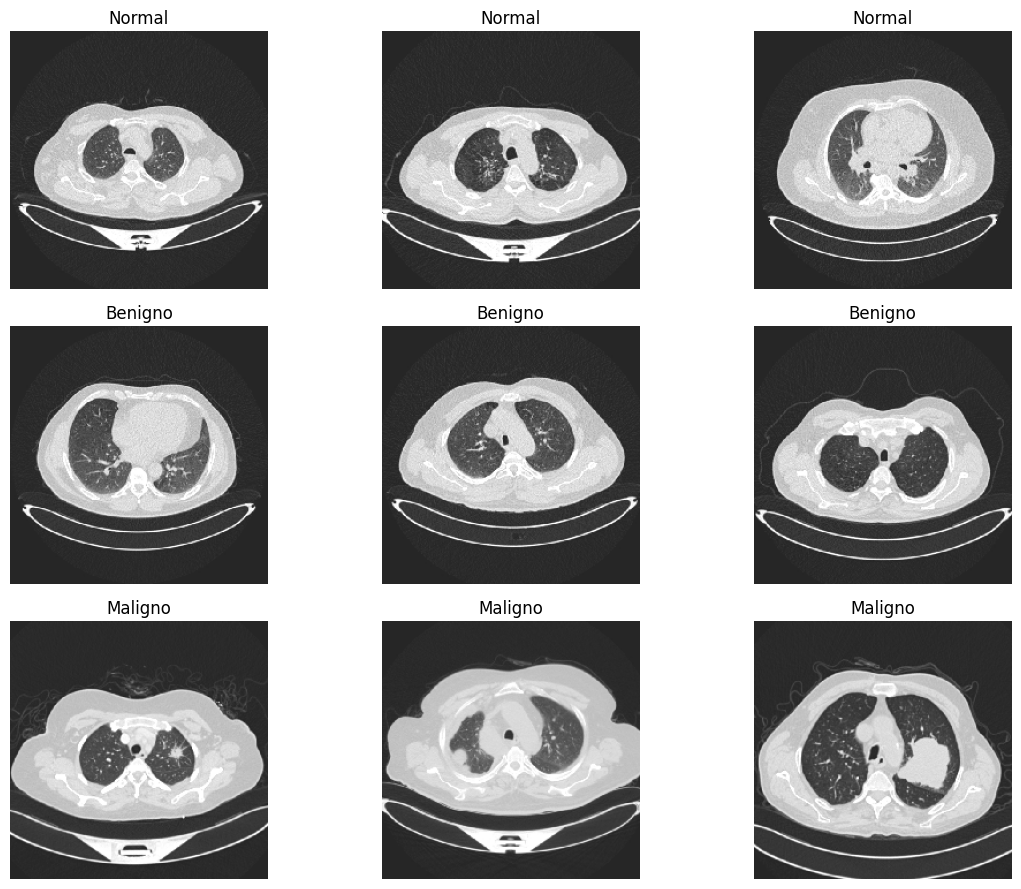

In [6]:
registros = coletar_registros_imagens(DATASET_DIR)
resumir_dataset(registros)
mostrar_exemplos(registros, amostras_por_classe=3, image_size=IMAGE_SIZE)

## Treino

A célula abaixo executa o pipeline completo de treinamento usando o dataset encontrado em `DATASET_DIR`. Ao final, o notebook salva o melhor modelo, consolida o histórico de treino e retorna os objetos necessários para a avaliação posterior.

Contagem por rotulo binario:
label
nao_maligno    536
maligno        561
Name: count, dtype: int64

Contagem por classe:
classe_original
Benigno    120
Maligno    561
Normal     416
Name: count, dtype: int64


Carregando imagens: 100%|██████████| 165/165 [00:00<00:00, 273.00it/s]
2026-05-05 08:20:03.459743: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-05-05 08:20:03.460146: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-05-05 08:20:03.460156: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-05-05 08:20:03.460427: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-05 08:20:03.460448: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Class weights: {0: 1.0226666666666666, 1: 0.9783163265306123}
Epoch 1/8


2026-05-05 08:20:12.900759: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


48/48 ━━━━━━━━━━━━━━━━━━━━ 33s 459ms/step - accuracy: 0.6063 - auc: 0.6359 - loss: 0.6719 - precision: 0.6273 - recall: 0.6286 - val_accuracy: 0.8788 - val_auc: 0.9893 - val_loss: 0.2943 - val_precision: 0.9851 - val_recall: 0.7765 - learning_rate: 1.0000e-04
Epoch 2/8
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 217ms/step - accuracy: 0.9156 - auc: 0.9796 - loss: 0.2567 - precision: 0.9333 - recall: 0.9055 - val_accuracy: 0.8667 - val_auc: 0.9926 - val_loss: 0.2464 - val_precision: 0.9846 - val_recall: 0.7529 - learning_rate: 1.0000e-04
Epoch 3/8
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 230ms/step - accuracy: 0.9381 - auc: 0.9891 - loss: 0.1782 - precision: 0.9413 - recall: 0.9396 - val_accuracy: 0.8788 - val_auc: 0.9943 - val_loss: 0.2202 - val_precision: 0.9851 - val_recall: 0.7765 - learning_rate: 1.0000e-04
Epoch 4/8
48/48 ━━━━━━━━━━━━━━━━━━━━ 15s 326ms/step - accuracy: 0.9608 - auc: 0.9937 - loss: 0.1374 - precision: 0.9556 - recall: 0.9684 - val_accuracy: 0.8667 - val_auc: 0.9949 - val_loss: 0.2345 - v

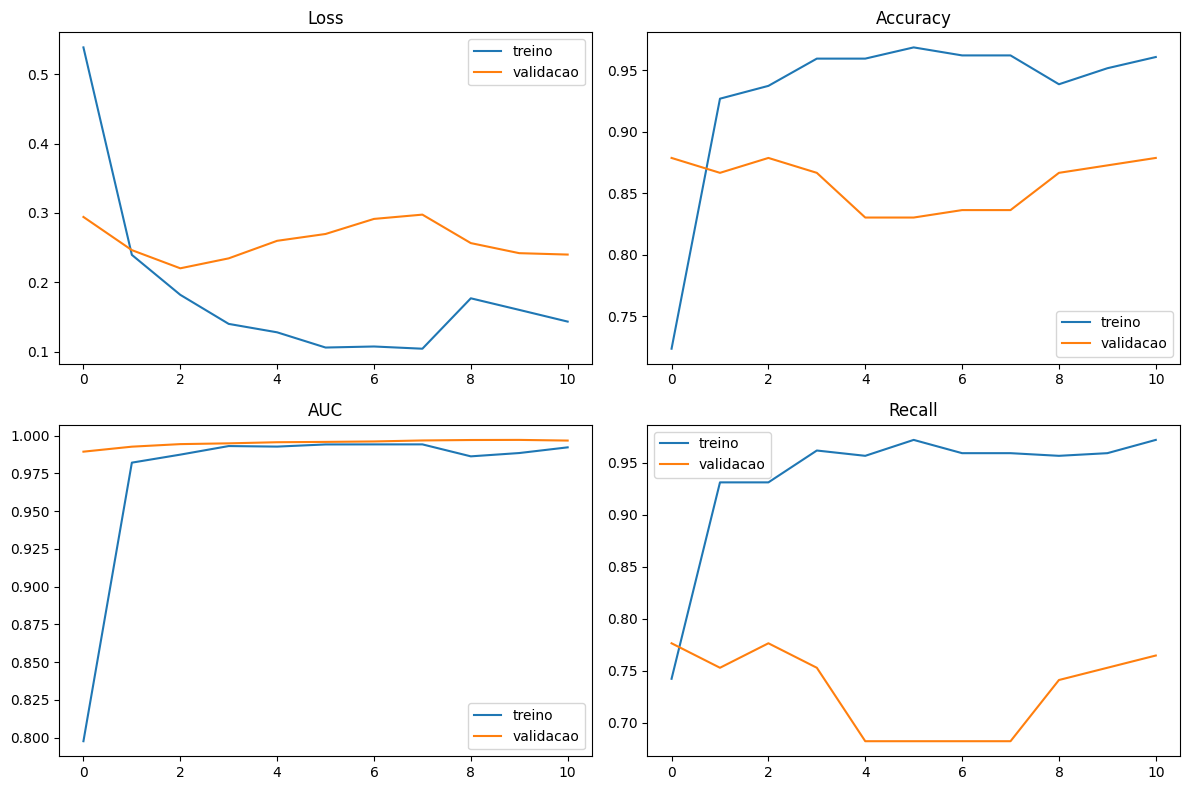

In [7]:

modelo, history, resultados = treinar_modelo(
    dataset_dir=DATASET_DIR,
    output_dir=OUTPUT_DIR,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    image_size=IMAGE_SIZE,
    seed=SEED,
    usar_class_weight=USAR_CLASS_WEIGHT,
    fine_tune_epochs=FINE_TUNE_EPOCHS,
)
plotar_curvas_treino(history)


## Avaliação

Depois do treino, esta etapa apresenta o desempenho final no conjunto de teste. São exibidas as métricas agregadas, a matriz de confusão, a curva ROC e a curva precision-recall para facilitar a interpretação dos acertos e erros do modelo.

{'accuracy': 0.9515151515151515, 'precision': 0.9523809523809523, 'recall': 0.9523809523809523, 'specificity': 0.9506172839506173, 'f1': 0.9523809523809523, 'tp': 80, 'tn': 77, 'fp': 4, 'fn': 4, 'auc_roc': 0.9976484420928866, 'average_precision': 0.9977975951382714, 'threshold': 0.1}


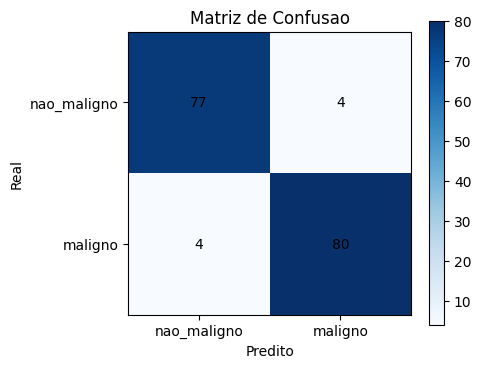

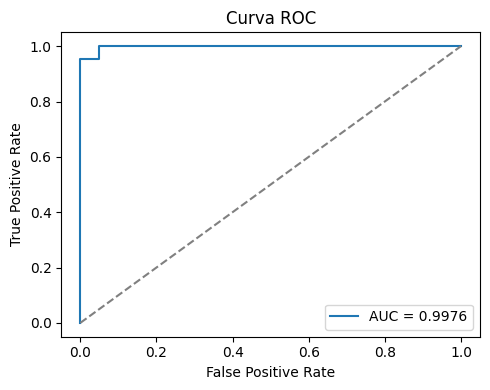

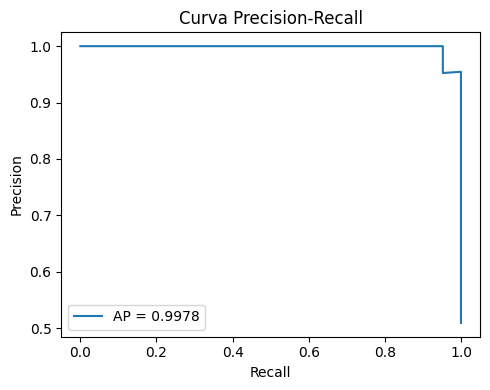

In [8]:
print(resultados["metricas_teste"])
plotar_matriz_confusao(
    resultados["y_test"],
    resultados["y_prob_test"],
    threshold=resultados["melhor_threshold"],
)

plotar_curva_roc(resultados["y_test"], resultados["y_prob_test"])
plotar_curva_precision_recall(resultados["y_test"], resultados["y_prob_test"])


## Inferência

Estas funções implementam o fluxo de previsão para novas imagens. O notebook recarrega o modelo salvo, reutiliza o `image_size` e o limiar aprendidos no treino e devolve a probabilidade de malignidade junto com a classe predita.

In [9]:
def carregar_modelo_treinado(checkpoint_path):
    checkpoint_path = Path(checkpoint_path)
    metadata_path = checkpoint_path.with_name("best_info.json")
    metadata = {}

    if metadata_path.exists():
        with metadata_path.open("r", encoding="utf-8") as file:
            metadata = json.load(file)

    model = keras.models.load_model(checkpoint_path)
    image_size = metadata.get("image_size", 224)
    threshold = metadata.get("best_threshold", 0.5)
    return model, image_size, threshold


def prever_com_modelo(model, image_path, image_size, threshold=0.5, verbose=True):
    image = carregar_tensor_imagem(str(image_path), image_size=image_size)
    probability = float(model.predict(image[np.newaxis, ...], verbose=0)[0][0])
    prediction = "maligno" if probability >= threshold else "nao_maligno"

    if verbose:
        print(f"probabilidade_malignidade={probability:.4f}")
        print(f"limiar_utilizado={float(threshold):.4f}")
        print(f"classe_predita={PREDICTION_DISPLAY[prediction]}")
    return probability, prediction


def prever_imagem(checkpoint_path, image_path, image_size=None, threshold=None, verbose=True):
    model, image_size_salvo, threshold_salvo = carregar_modelo_treinado(checkpoint_path)
    image_size = image_size or image_size_salvo
    threshold = threshold if threshold is not None else threshold_salvo
    return prever_com_modelo(model, image_path, image_size=image_size, threshold=threshold, verbose=verbose)


In [10]:
def demonstrar_previsoes_exemplo(checkpoint_path, dataset_dir, image_size=None):
    checkpoint_path = Path(checkpoint_path)
    dataset_dir = Path(dataset_dir)
    image_size = image_size or globals().get("IMAGE_SIZE", 224)

    exemplos = [
        ("Normal cases", "Normal case (1).jpg"),
        ("Bengin cases", "Bengin case (1).jpg"),
        ("Malignant cases", "Malignant case (1).jpg"),
    ]
    cores_predicao = {
        "Nao maligno": "seagreen",
        "Maligno": "firebrick",
    }

    if not checkpoint_path.exists():
        print(f"Modelo nao encontrado em: {checkpoint_path}")
        print("Execute a secao de treino antes desta demonstracao.")
        return None

    model, image_size_salvo, threshold_salvo = carregar_modelo_treinado(checkpoint_path)
    image_size = image_size or image_size_salvo

    linhas = []
    imagens_plot = []
    for nome_pasta, nome_arquivo in exemplos:
        image_path = dataset_dir / nome_pasta / nome_arquivo
        if not image_path.exists():
            print(f"Imagem nao encontrada: {image_path}")
            continue

        probability, prediction = prever_com_modelo(
            model=model,
            image_path=image_path,
            image_size=image_size,
            threshold=threshold_salvo,
            verbose=False,
        )
        prediction_exibicao = PREDICTION_DISPLAY[prediction]
        esperado = nome_exibicao_classe(nome_pasta)
        linhas.append(
            {
                "classe": nome_exibicao_classe(nome_pasta),
                "arquivo": nome_arquivo,
                "classe_esperada": esperado,
                "probabilidade_malignidade": round(probability, 4),
                "classe_predita": prediction_exibicao,
            }
        )
        imagens_plot.append((nome_pasta, nome_arquivo, image_path, esperado, probability, prediction_exibicao))

    if not linhas:
        print("Nenhum exemplo foi executado.")
        return None

    fig, axes = plt.subplots(1, len(imagens_plot), figsize=(5 * len(imagens_plot), 5))
    if len(imagens_plot) == 1:
        axes = [axes]

    for ax, (nome_pasta, nome_arquivo, image_path, esperado, probability, prediction_exibicao) in zip(axes, imagens_plot):
        image = keras.utils.load_img(
            image_path,
            color_mode="rgb",
            target_size=(image_size, image_size),
        )
        ax.imshow(image)
        ax.axis("off")
        cor_titulo = cores_predicao.get(prediction_exibicao, "black")
        ax.set_title(
            f"{nome_exibicao_classe(nome_pasta)}\n{nome_arquivo}\nesperado={esperado}\npred={prediction_exibicao} | prob={probability:.4f}",
            fontsize=10,
            color=cor_titulo,
        )

    plt.suptitle("Demonstracao de previsoes com imagens de exemplo", fontsize=14)
    plt.tight_layout()
    plt.show()

    resultados_df = pd.DataFrame(linhas)
    print("\nResumo dos exemplos:")
    print(resultados_df.to_string(index=False))
    return resultados_df


## Demonstração com `prever_imagem`

A célula abaixo usa o modelo salvo em `best.keras` para testar três imagens de exemplo do dataset e mostrar uma visualização lado a lado:

- uma imagem normal
- uma imagem benigna
- uma imagem maligna

Cada imagem aparece com a classe esperada, a classe predita e a probabilidade de malignidade. Títulos verdes indicam `nao_maligno` e vermelhos indicam `maligno`, o que ajuda a validar rapidamente o comportamento do modelo em exemplos reais.

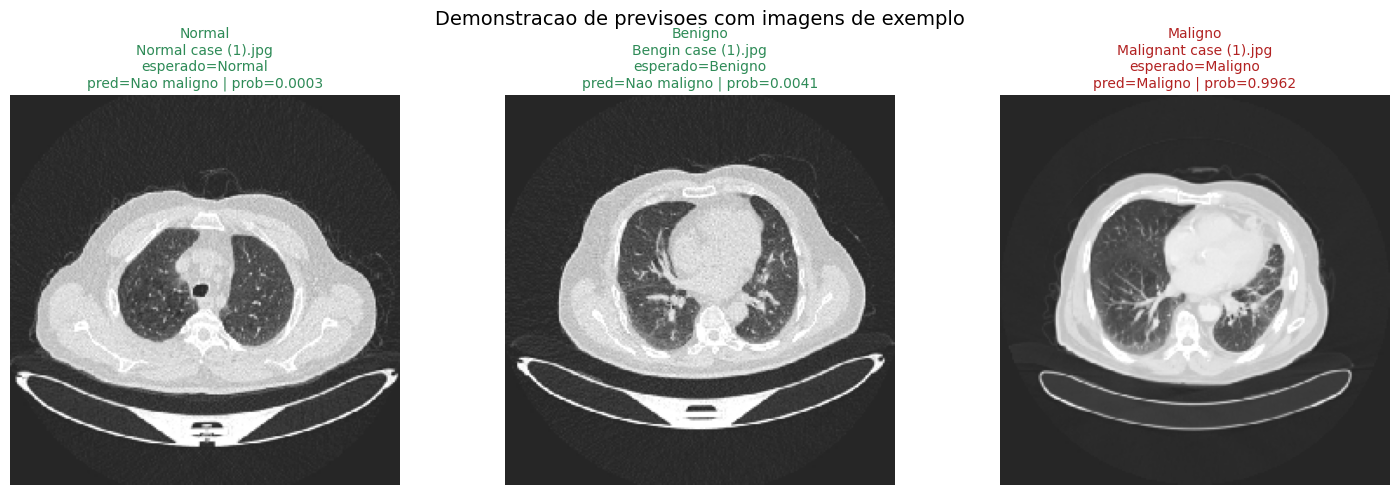


Resumo dos exemplos:
 classe                arquivo classe_esperada  probabilidade_malignidade classe_predita
 Normal    Normal case (1).jpg          Normal                     0.0003    Nao maligno
Benigno    Bengin case (1).jpg         Benigno                     0.0041    Nao maligno
Maligno Malignant case (1).jpg         Maligno                     0.9962        Maligno


In [11]:
resultados_exemplo = demonstrar_previsoes_exemplo(
    checkpoint_path=OUTPUT_DIR / "best.keras",
    dataset_dir=DATASET_DIR,
)
